# Ecommerce Customer Churn — EDA & NA Cleaning

## 1. Import Required Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load Dataset

In [6]:
df = pd.read_csv("data/Ecommerce Customer Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## 3. Explore Missing Values

In [7]:
print("=== dtypes & non-null counts ===")
df.info()

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null 

In [8]:
na_count = df.isnull().sum()
na_pct   = (na_count / len(df) * 100).round(2)
na_summary = pd.DataFrame({"NA Count": na_count, "NA %": na_pct})
na_summary = na_summary[na_summary["NA Count"] > 0].sort_values("NA Count", ascending=False)
print(na_summary)

                             NA Count  NA %
DaySinceLastOrder                 307  5.45
OrderAmountHikeFromlastYear       265  4.71
Tenure                            264  4.69
OrderCount                        258  4.58
CouponUsed                        256  4.55
HourSpendOnApp                    255  4.53
WarehouseToHome                   251  4.46


## 4. Visualise Missing Data

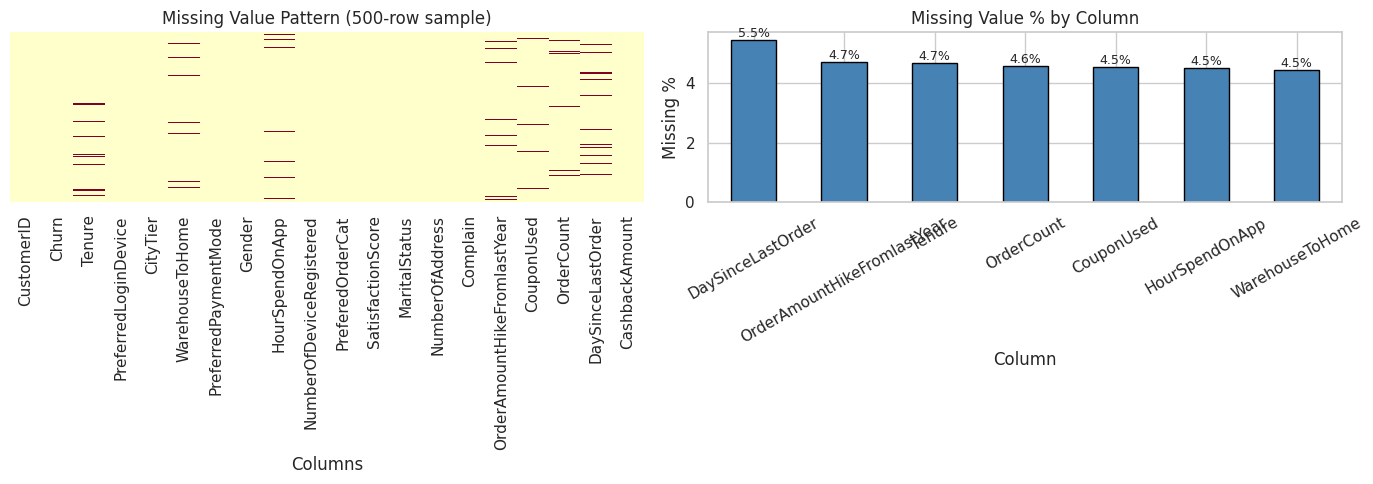

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap (sample 500 rows for readability)
sample = df.sample(500, random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Missing Value Pattern (500-row sample)")
axes[0].set_xlabel("Columns")

# Bar chart
na_summary["NA %"].plot(kind="bar", color="steelblue", edgecolor="black", ax=axes[1])
axes[1].set_title("Missing Value % by Column")
axes[1].set_ylabel("Missing %")
axes[1].set_xlabel("Column")
axes[1].tick_params(axis="x", rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Clean Missing Data

Strategy: fill each numeric column that has NAs with its **median** (robust to skew / outliers).

In [16]:
na_cols = na_summary.index.tolist()
print("Columns to fill:", na_cols)

df_clean = df.copy()
for col in na_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled {na_summary.loc[col, 'NA Count']} NAs with median={median_val}")

print(f"\nRemaining NAs after cleaning: {df_clean.isnull().sum().sum()}")

Columns to fill: ['DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'Tenure', 'OrderCount', 'CouponUsed', 'HourSpendOnApp', 'WarehouseToHome']
  DaySinceLastOrder: filled 307 NAs with median=3.0
  OrderAmountHikeFromlastYear: filled 265 NAs with median=15.0
  Tenure: filled 264 NAs with median=9.0
  OrderCount: filled 258 NAs with median=2.0
  CouponUsed: filled 256 NAs with median=1.0
  HourSpendOnApp: filled 255 NAs with median=3.0
  WarehouseToHome: filled 251 NAs with median=14.0

Remaining NAs after cleaning: 0


## 6. Compare Before and After Cleaning

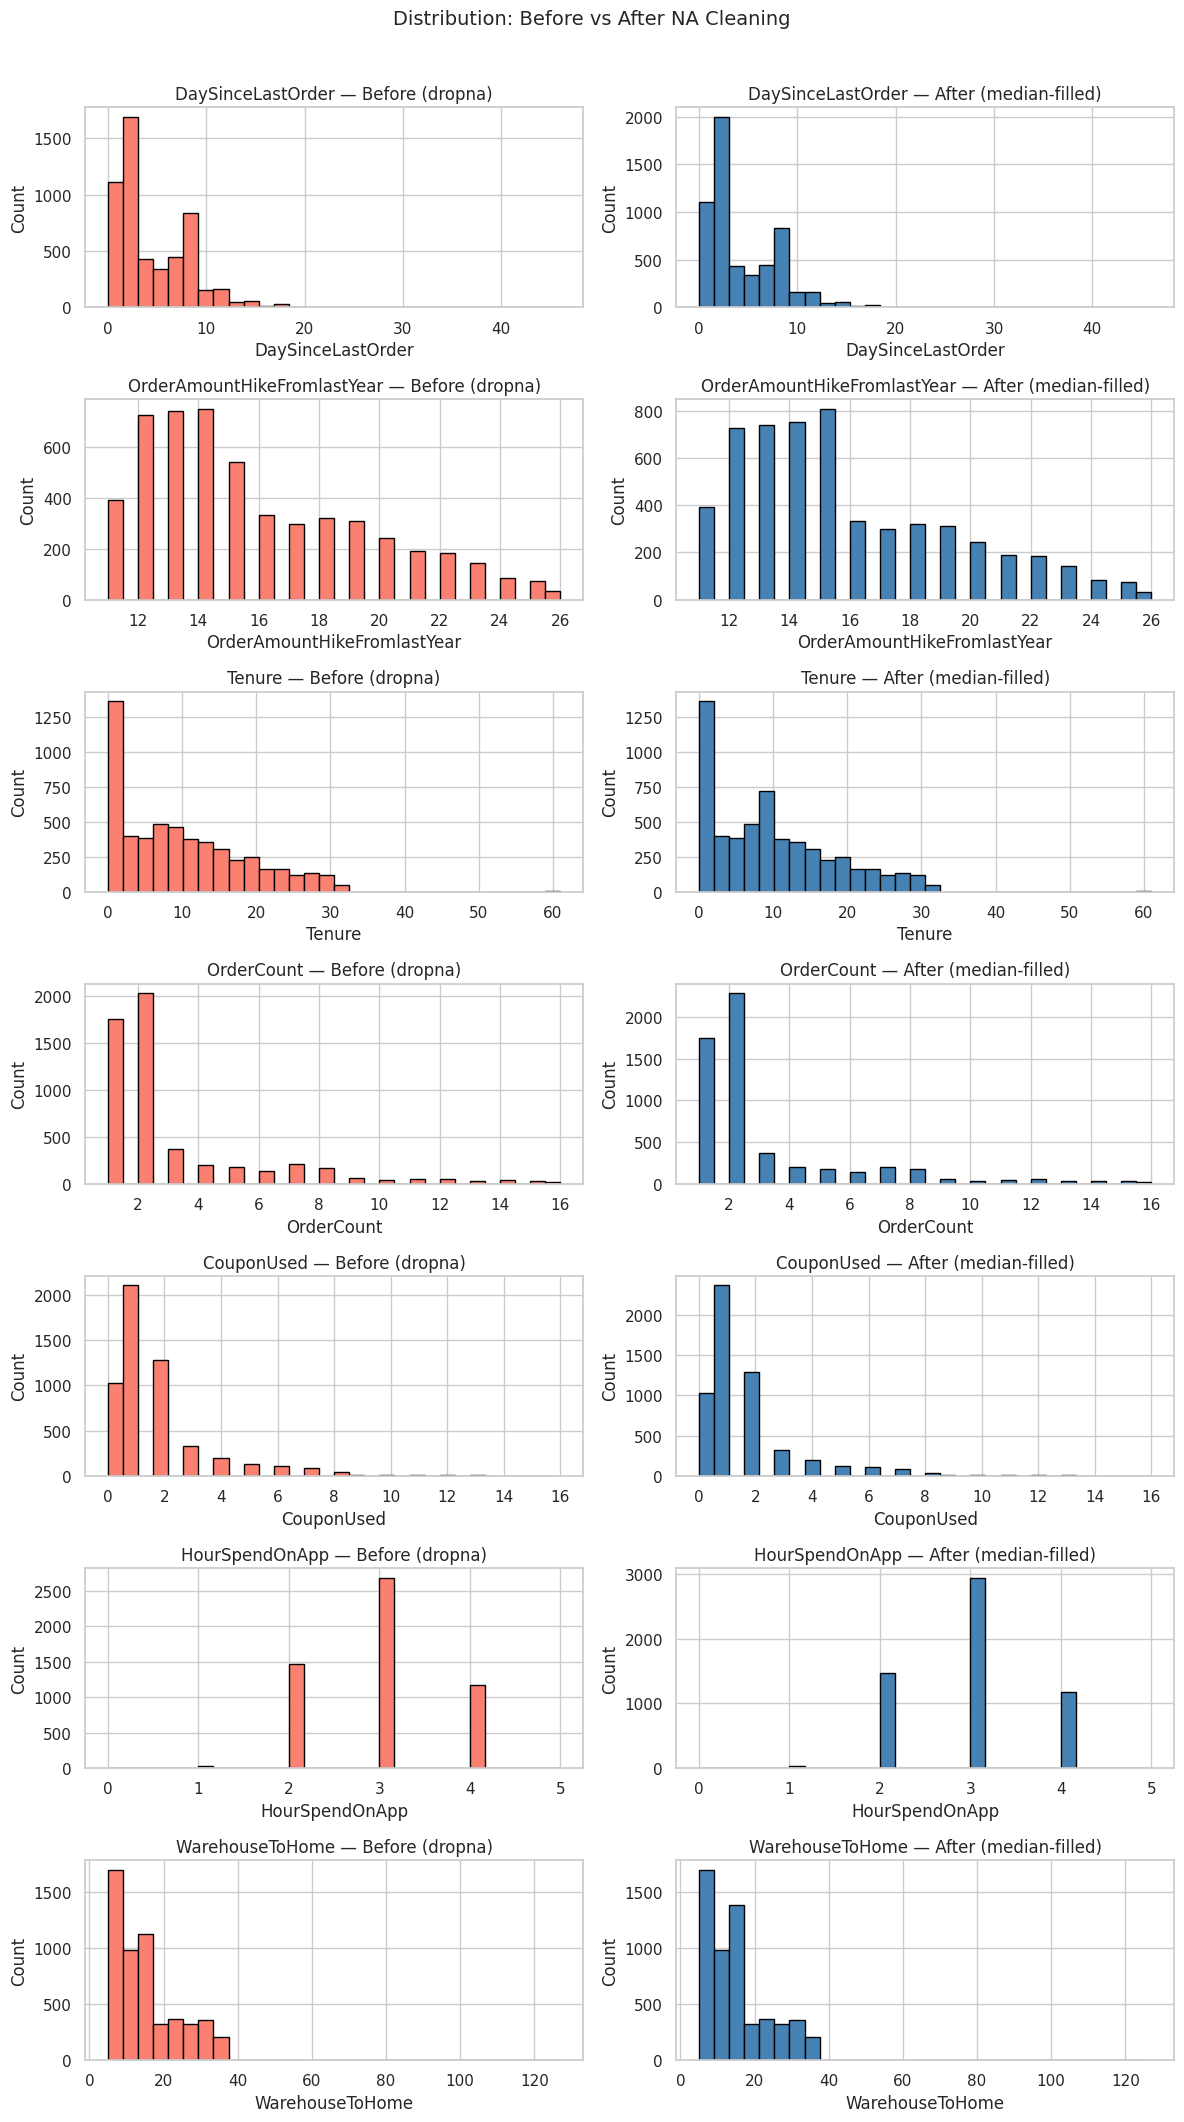

In [11]:
fig, axes = plt.subplots(len(na_cols), 2, figsize=(12, len(na_cols) * 3))

for i, col in enumerate(na_cols):
    # Before
    axes[i, 0].hist(df[col].dropna(), bins=30, color="salmon", edgecolor="black")
    axes[i, 0].set_title(f"{col} — Before (dropna)")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    # After
    axes[i, 1].hist(df_clean[col], bins=30, color="steelblue", edgecolor="black")
    axes[i, 1].set_title(f"{col} — After (median-filled)")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Count")

plt.suptitle("Distribution: Before vs After NA Cleaning", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Churn vs Non-Churn by Feature

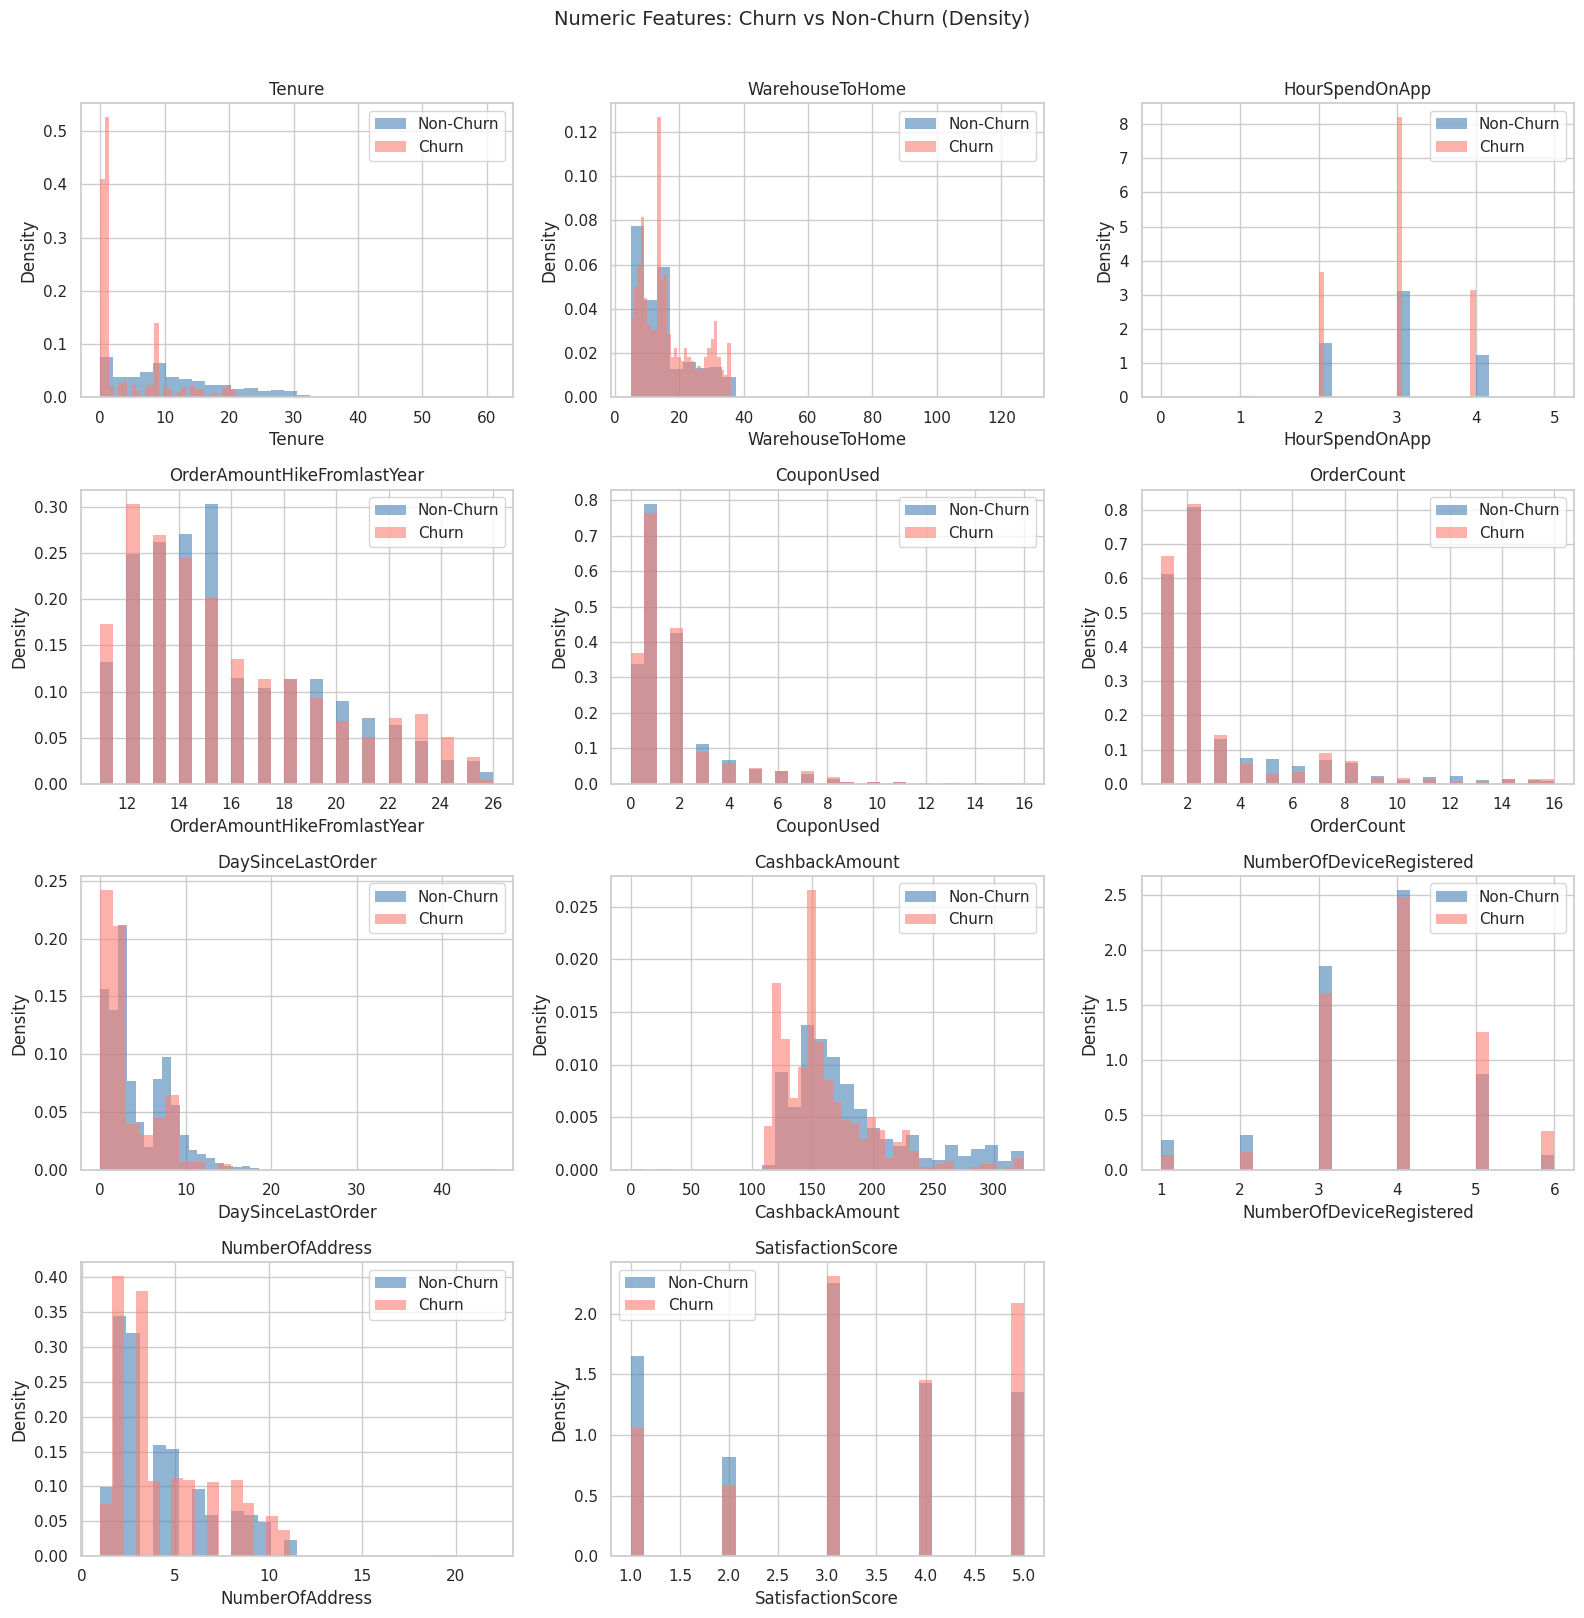

In [12]:
num_cols = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount",
    "DaySinceLastOrder", "CashbackAmount",
    "NumberOfDeviceRegistered", "NumberOfAddress", "SatisfactionScore"
]

n = len(num_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, (n + 2) // 3 * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, label, color in [(0, "Non-Churn", "steelblue"), (1, "Churn", "salmon")]:
        subset = df_clean[df_clean["Churn"] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="none", density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend()

# hide unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Features: Churn vs Non-Churn (Density)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

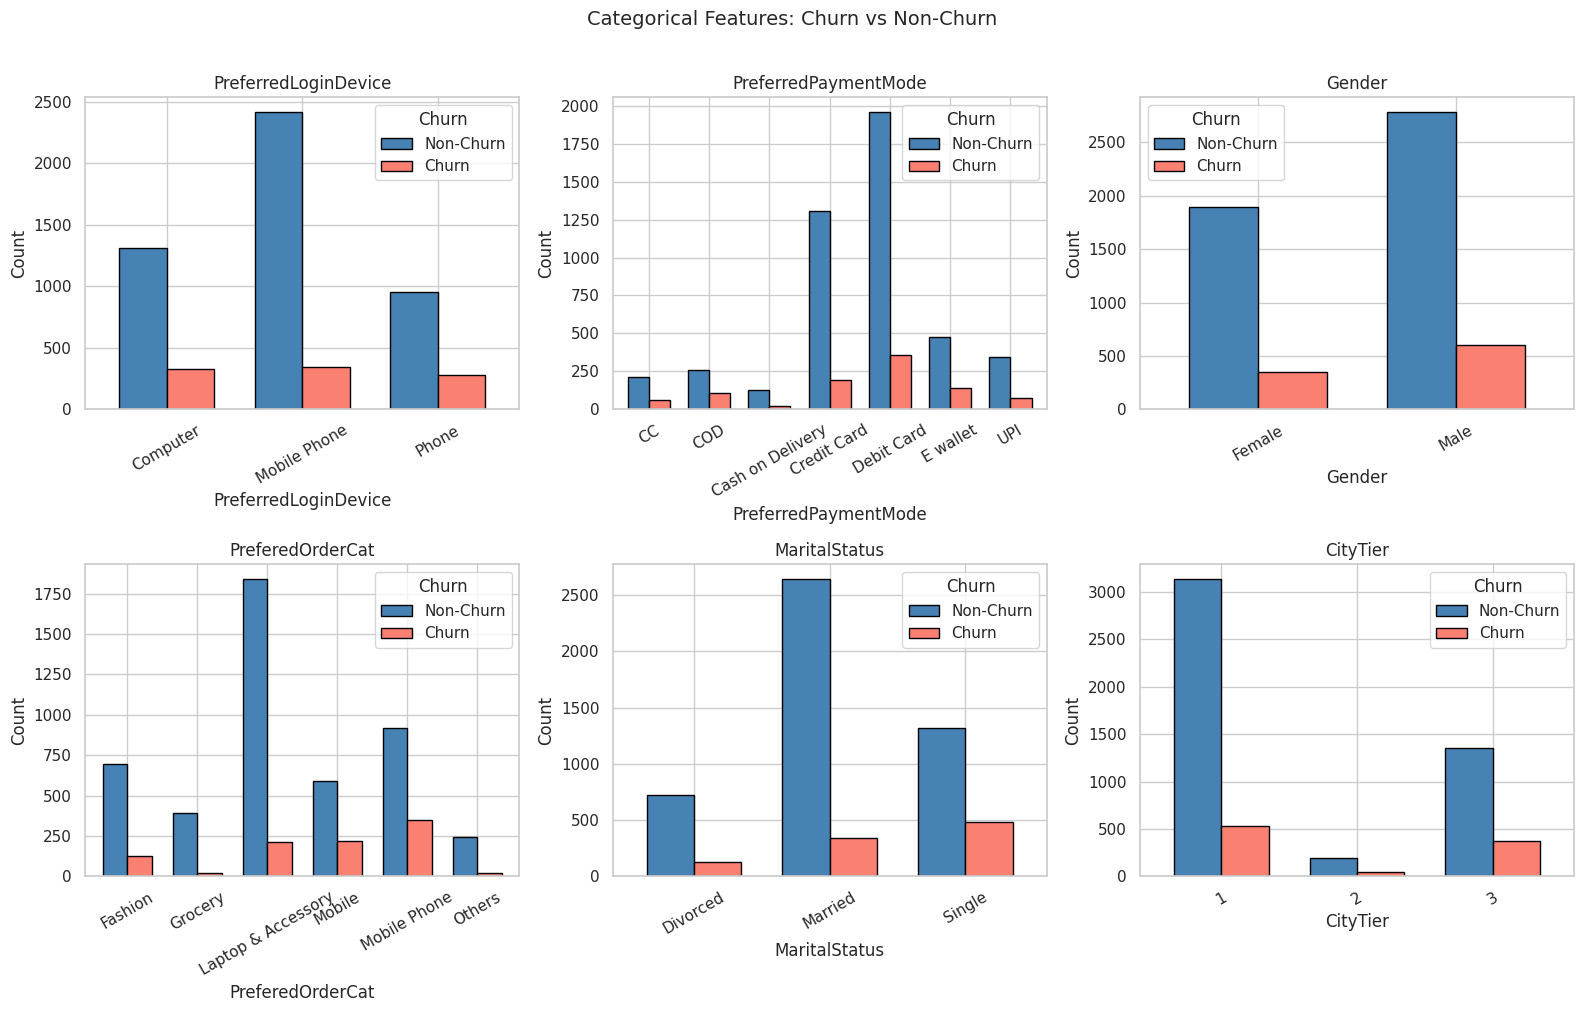

In [13]:
cat_cols = [
    "PreferredLoginDevice", "PreferredPaymentMode",
    "Gender", "PreferedOrderCat", "MaritalStatus", "CityTier"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = (df_clean.groupby([col, "Churn"])
          .size()
          .unstack(fill_value=0)
          .rename(columns={0: "Non-Churn", 1: "Churn"}))
    ct.plot(kind="bar", ax=axes[i], color=["steelblue", "salmon"],
            edgecolor="black", width=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Churn")

plt.suptitle("Categorical Features: Churn vs Non-Churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Scatter Plots — Numeric Feature Pairs vs Churn

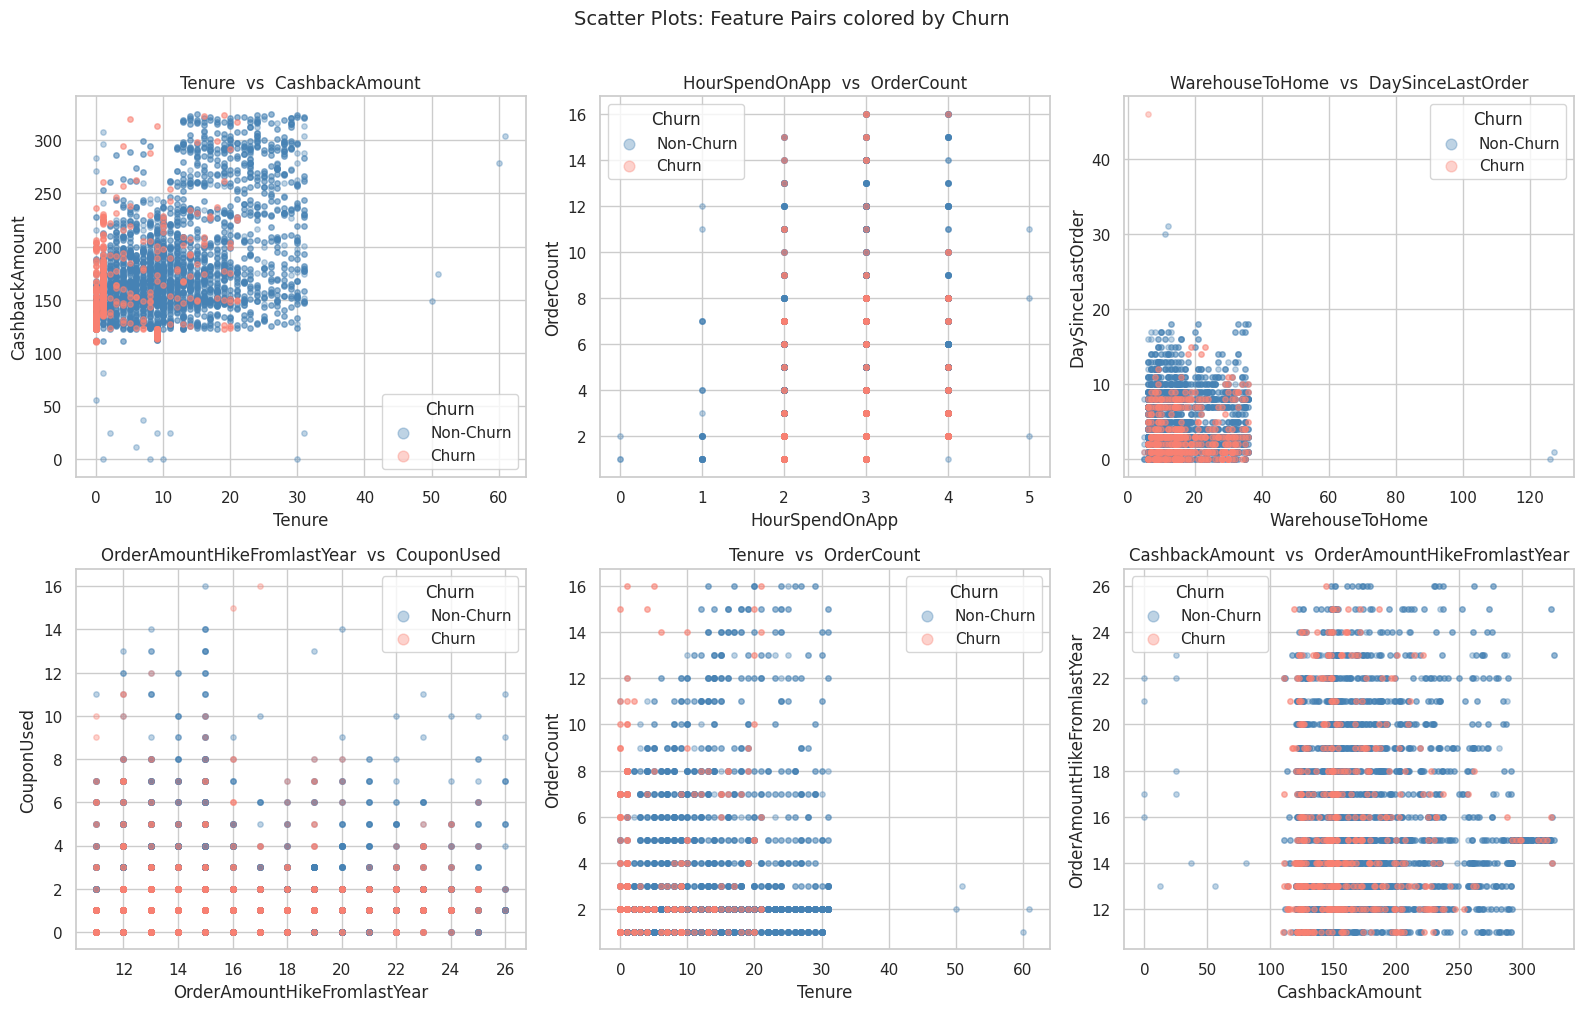

In [14]:
scatter_pairs = [
    ("Tenure",              "CashbackAmount"),
    ("HourSpendOnApp",      "OrderCount"),
    ("WarehouseToHome",     "DaySinceLastOrder"),
    ("OrderAmountHikeFromlastYear", "CouponUsed"),
    ("Tenure",              "OrderCount"),
    ("CashbackAmount",      "OrderAmountHikeFromlastYear"),
]

colors = {0: "steelblue", 1: "salmon"}
labels = {0: "Non-Churn", 1: "Churn"}

n = len(scatter_pairs)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, (n + 2) // 3 * 5))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(scatter_pairs):
    for churn_val in [0, 1]:
        subset = df_clean[df_clean["Churn"] == churn_val]
        axes[i].scatter(
            subset[x_col], subset[y_col],
            alpha=0.35, s=15,
            color=colors[churn_val],
            label=labels[churn_val]
        )
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f"{x_col}  vs  {y_col}")
    axes[i].legend(title="Churn", markerscale=2)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Scatter Plots: Feature Pairs colored by Churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Pairplot — Key Numeric Features by Churn

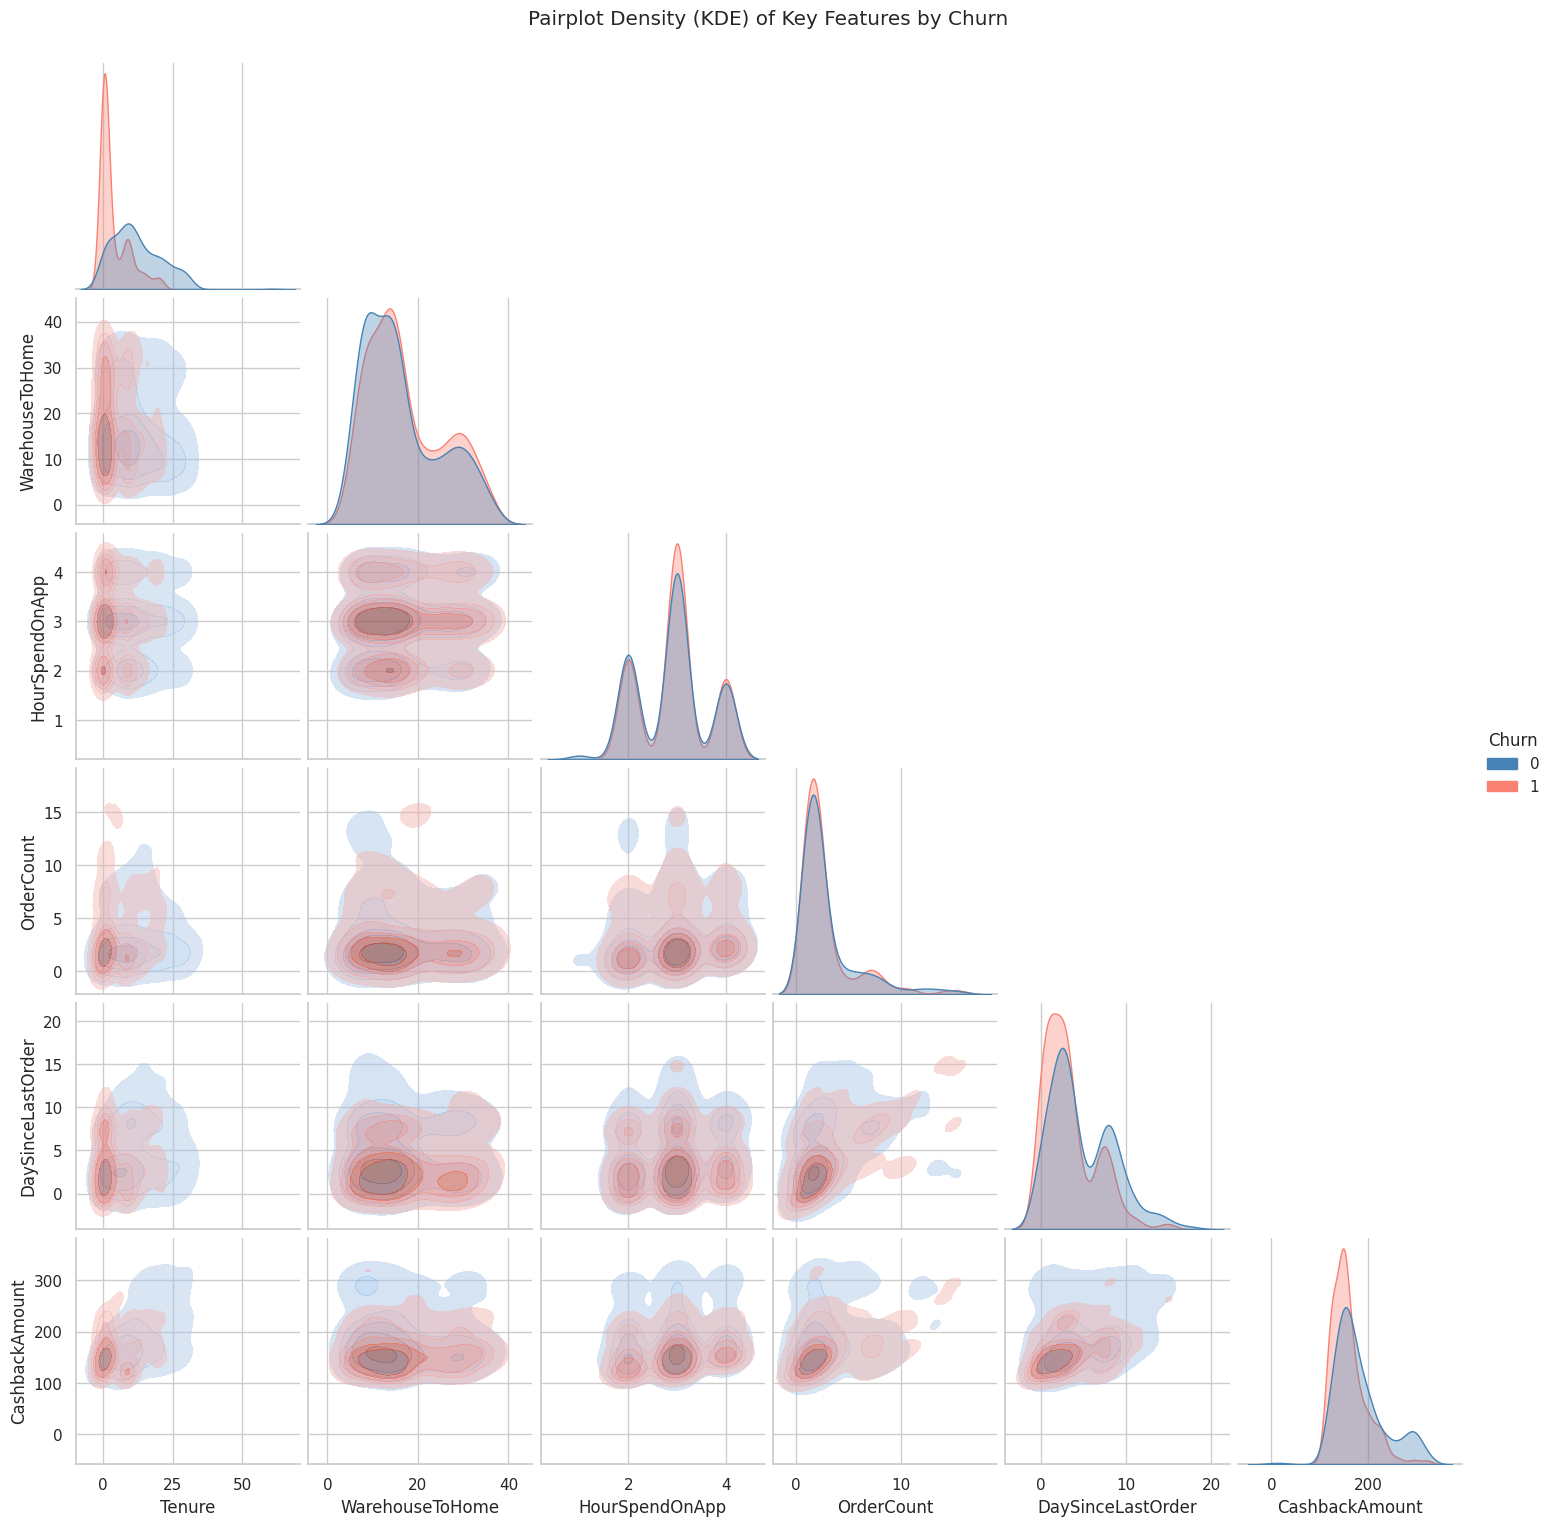

In [19]:
pairplot_cols = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderCount", "DaySinceLastOrder", "CashbackAmount",
    "Churn"
]

# Sample for faster rendering (keep class ratio by sampling within each churn class).
base = df_clean[pairplot_cols].dropna()
pairplot_data = pd.concat(
    [
        grp.sample(n=min(400, len(grp)), random_state=42)
        for _, grp in base.groupby("Churn")
    ],
    ignore_index=True
)

g = sns.pairplot(
    data=pairplot_data,
    vars=[c for c in pairplot_cols if c != "Churn"],
    hue="Churn",
    corner=True,
    kind="kde",
    diag_kind="kde",
    plot_kws={"fill": True, "levels": 6, "thresh": 0.05, "alpha": 0.45},
    diag_kws={"fill": True, "common_norm": False, "alpha": 0.35},
    palette={0: "steelblue", 1: "salmon"}
)

g.fig.suptitle("Pairplot Density (KDE) of Key Features by Churn", y=1.02)
plt.show()